In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

sns.set(rc={'figure.figsize':(11.7,8.27)})
train_cols = ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants','AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies','HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice','BMI']

In [4]:
data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
data = data.reset_index(drop=True)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Diabetes'}>,
        <Axes: title={'center': 'BloodPressureProblems'}>],
       [<Axes: title={'center': 'AnyTransplants'}>,
        <Axes: title={'center': 'AnyChronicDiseases'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'KnownAllergies'}>,
        <Axes: title={'center': 'HistoryOfCancerInFamily'}>],
       [<Axes: title={'center': 'NumberOfMajorSurgeries'}>,
        <Axes: title={'center': 'PremiumPrice'}>,
        <Axes: title={'center': 'BMI'}>]], dtype=object)

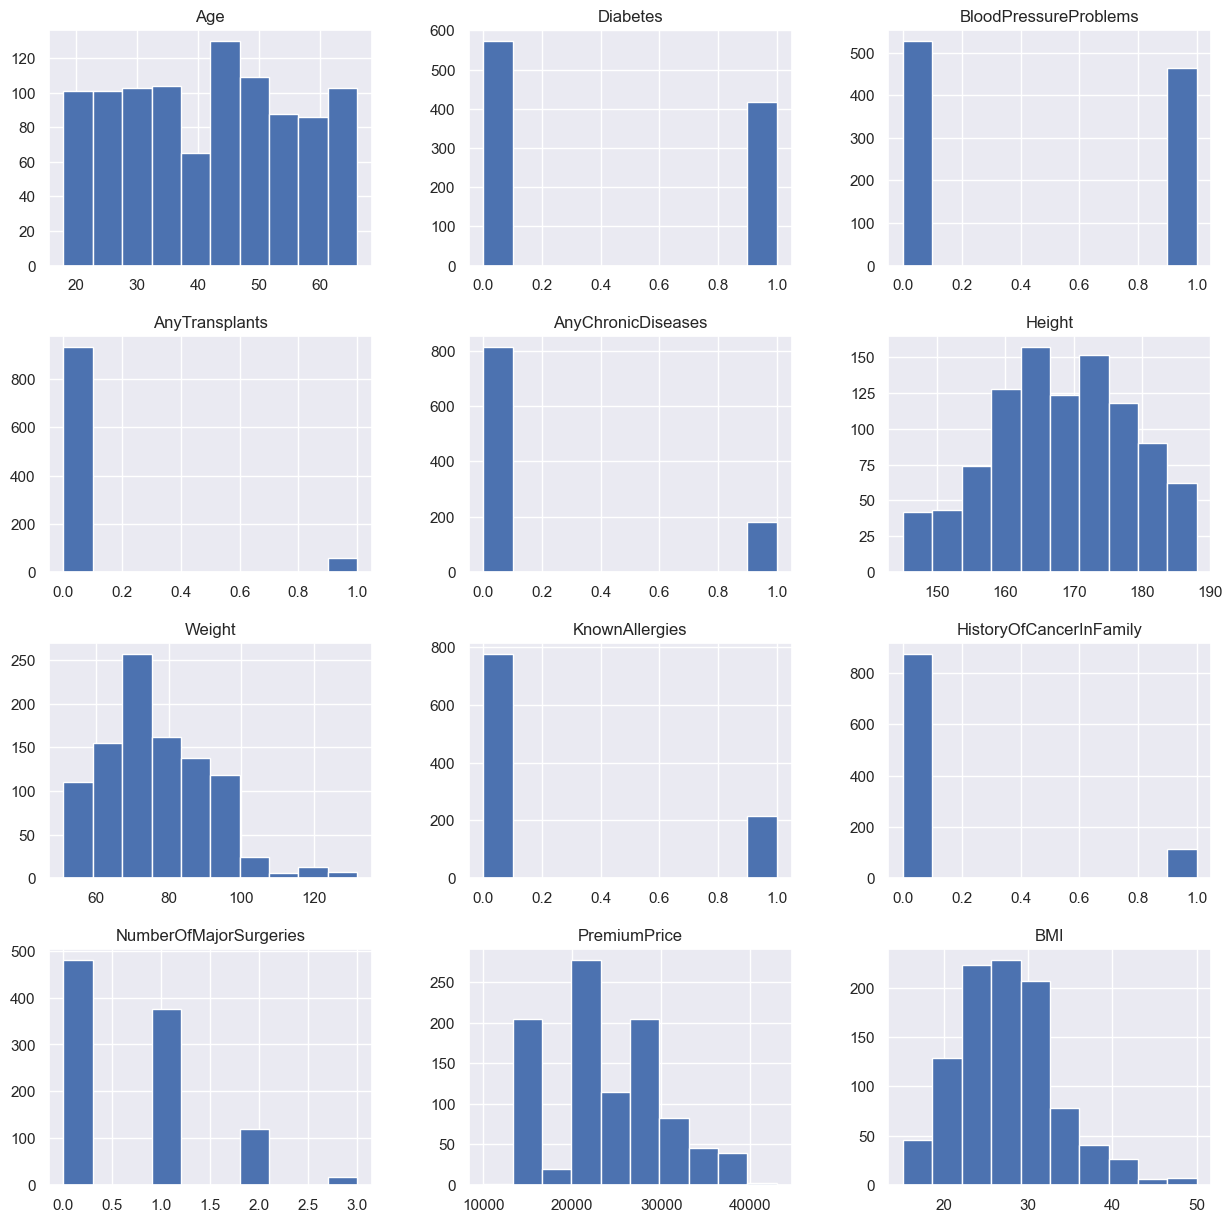

In [59]:
data.hist(figsize=(15,15))

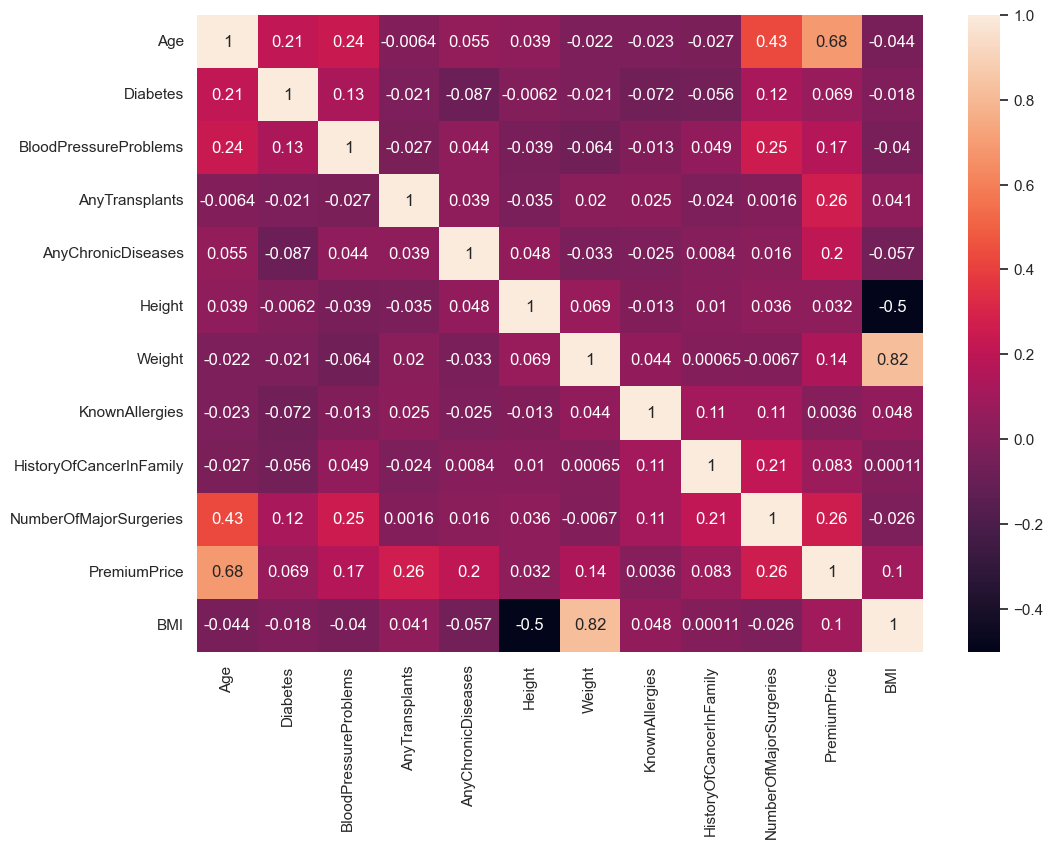

In [60]:
plt.close()
sns.heatmap(data[train_cols].corr(),annot=True)
plt.show()

In [61]:
k = 10 #10 # 3 Number of neighbors (k)
nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto',metric='l1').fit(data[train_cols])

In [62]:
distances, indices = nbrs.kneighbors(data[train_cols])

data['knn_distances'] = np.mean(distances, axis=1) # k-NN distances for each point
data['neighbors'] = indices.tolist()
data['neighbors_dist'] = distances.tolist()
threshold = np.mean(data['knn_distances']) + 2 * np.std(data['knn_distances']) # Mean + 2 * std

anomalies = data['knn_distances'] > threshold
data['Is Anomaly'] = anomalies

In [63]:
anomali_data_knn = data[data['Is Anomaly'] == True]

In [64]:
threshold

502.42240451822914

In [65]:
distances

array([[0.00000000e+00, 5.89240681e+00, 6.51294099e+00, ...,
        1.84171362e+01, 1.84563439e+01, 1.86772385e+01],
       [0.00000000e+00, 4.50915600e+00, 8.68142919e+00, ...,
        1.11887451e+01, 1.12482721e+01, 1.25260706e+01],
       [0.00000000e+00, 8.15270394e+00, 1.01989716e+01, ...,
        1.50513238e+01, 1.63207546e+01, 1.69757007e+01],
       ...,
       [0.00000000e+00, 3.94638493e+01, 4.23047882e+01, ...,
        1.02051229e+03, 1.02058673e+03, 1.02387636e+03],
       [0.00000000e+00, 6.13450561e+01, 1.07271363e+03, ...,
        2.04034199e+03, 2.04540485e+03, 2.04669682e+03],
       [0.00000000e+00, 5.03156250e+03, 5.03300687e+03, ...,
        5.03999766e+03, 5.04015836e+03, 5.04016810e+03]])

# K means


In [ ]:
# data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
# # data = data.drop('ID',axis=1)
# data = data.reset_index(drop=True)

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_clusters = 2  # Start with 2 clusters

range_of_clusters = range(2, 100)

for k in range_of_clusters:
    kmeans = KMeans(n_clusters=k, random_state=0,n_init='auto')
    kmeans.fit(data[train_cols])
    labels = kmeans.labels_
    score = silhouette_score(data[train_cols], labels)
    
    if score > best_score:
        best_score = score
        best_clusters = k

print(f"Best number of clusters: {best_clusters}")
print(f"Best silhouette score: {best_score}")

Best number of clusters: 26
Best silhouette score: 0.9709711034690562


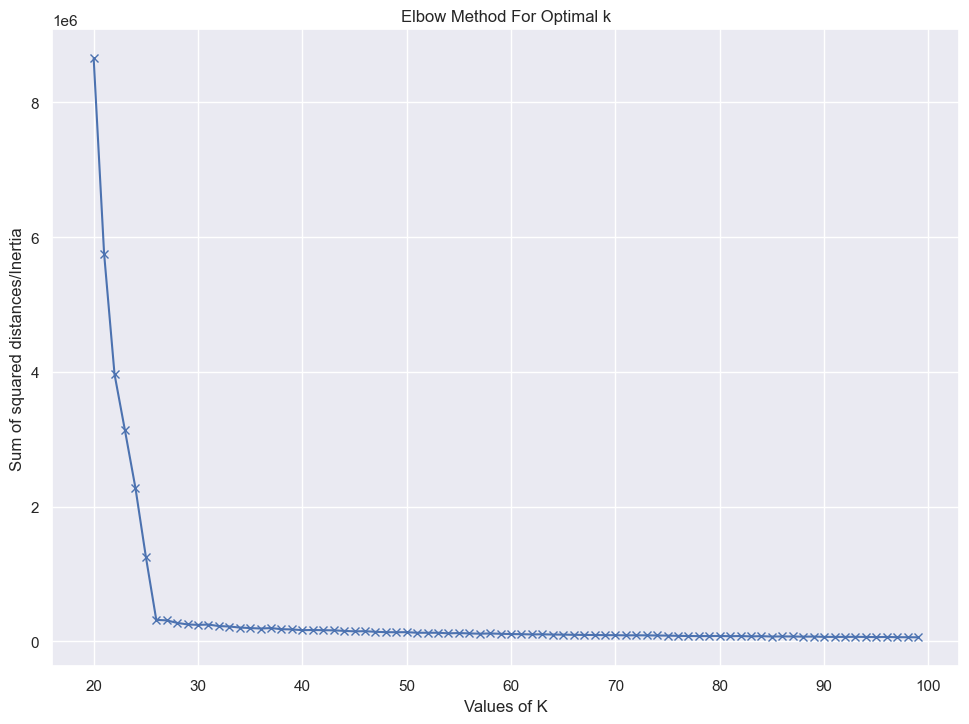

In [67]:
Sum_of_squared_distances = []
K = range(20,100)
for num_clusters in K :
 kmeans = KMeans(n_clusters=num_clusters,n_init='auto')
 kmeans.fit(data[train_cols])
 Sum_of_squared_distances.append(kmeans.inertia_)
plt.plot(K,Sum_of_squared_distances,'bx-')
plt.xlabel('Values of K') 
plt.ylabel('Sum of squared distances/Inertia') 
plt.title('Elbow Method For Optimal k')
plt.show()

In [68]:
k = 26 
kmeans = KMeans(n_clusters=k, random_state=0,n_init='auto')
kmeans.fit(data[train_cols])
data['Cluster'] = kmeans.labels_

# Euclidean distance between each data point and its cluster center
data['Distance to Center'] = np.linalg.norm(data[train_cols] - kmeans.cluster_centers_[kmeans.labels_], axis=1)

threshold = data['Distance to Center'].quantile(0.90) 
anomalies = data['Distance to Center'] > threshold
data['Is Anomaly'] = anomalies

In [118]:
anomali_data = data[data['Is Anomaly'] == True]
anomali_data

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,knn_distances,neighbors,neighbors_dist,Is Anomaly,Cluster,Distance to Center,LocalOutlierFactor
22,35,0,0,0,0,163,92,0,0,1,32000,34.626821,624.988504,"[22, 650, 53, 46, 303, 627, 140, 194, 360, 518]","[0.0, 22.025813900000003, 22.866950529999997, ...",True,-1,8.860008,-1
46,25,1,1,0,0,179,69,0,0,0,32000,21.534908,639.638363,"[46, 53, 22, 650, 435, 451, 935, 870, 618, 680]","[0.0, 58.2249618, 65.09191233, 77.11772623, 10...",True,-1,25.605602,-1
53,43,0,0,0,0,172,91,0,0,0,32000,30.759870,622.288178,"[53, 22, 650, 46, 360, 518, 194, 613, 545, 627]","[0.0, 22.866950529999997, 26.89276443, 58.2249...",True,-1,8.036191,-1
58,23,0,1,0,0,156,79,0,0,0,24000,32.462196,537.544839,"[58, 987, 311, 212, 217, 171, 794, 50, 972, 237]","[0.0, 42.30478816, 49.1590611, 77.46219592, 11...",True,-1,30.652887,-1
202,30,0,0,0,0,177,96,1,0,1,26000,30.642536,331.798042,"[202, 219, 556, 555, 280, 203, 324, 825, 584, ...","[0.0, 24.106370069999997, 24.61960501, 29.6279...",True,-1,5.947566,-1
203,24,0,1,0,0,173,128,0,0,1,26000,42.767884,363.230797,"[203, 219, 556, 202, 555, 280, 324, 825, 584, ...","[0.0, 46.01897825, 53.50574331, 56.12534832, 8...",True,-1,36.305893,-1
204,27,0,1,0,0,159,120,1,1,1,39000,47.466477,565.369930,"[204, 976, 926, 984, 928, 218, 86, 79, 101, 740]","[0.0, 75.66522810000001, 79.96436059, 88.22436...",True,-1,42.967592,-1
212,60,1,0,0,0,175,98,0,0,0,24000,32.000000,536.472439,"[212, 311, 217, 987, 58, 583, 625, 535, 674, 592]","[0.0, 45.69686518, 47.21832807, 63.76698408, 7...",True,-1,21.418290,-1
213,46,0,0,0,0,170,111,0,1,1,22000,38.408304,925.461247,"[213, 196, 535, 206, 177, 165, 193, 188, 350, ...","[0.0, 1024.22705024, 1025.49629162, 1025.75471...",True,-1,0.000000,-1
217,65,0,1,0,0,177,126,0,0,2,24000,40.218328,561.349670,"[217, 212, 987, 311, 58, 196, 206, 158, 177, 583]","[0.0, 47.21832807, 83.45134399, 88.91519325, 1...",True,-1,37.268868,-1


In [70]:
silhouette_avg = silhouette_score(data[train_cols], data['Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9709711034690562


Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.

1: Means clusters are well apart from each other and clearly distinguished.

0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.

-1: Means clusters are assigned in the wrong way.

[https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c]

# DBSCAN

In [ ]:
# data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
# # data = data.drop('ID',axis=1)
# data = data.reset_index(drop=True)

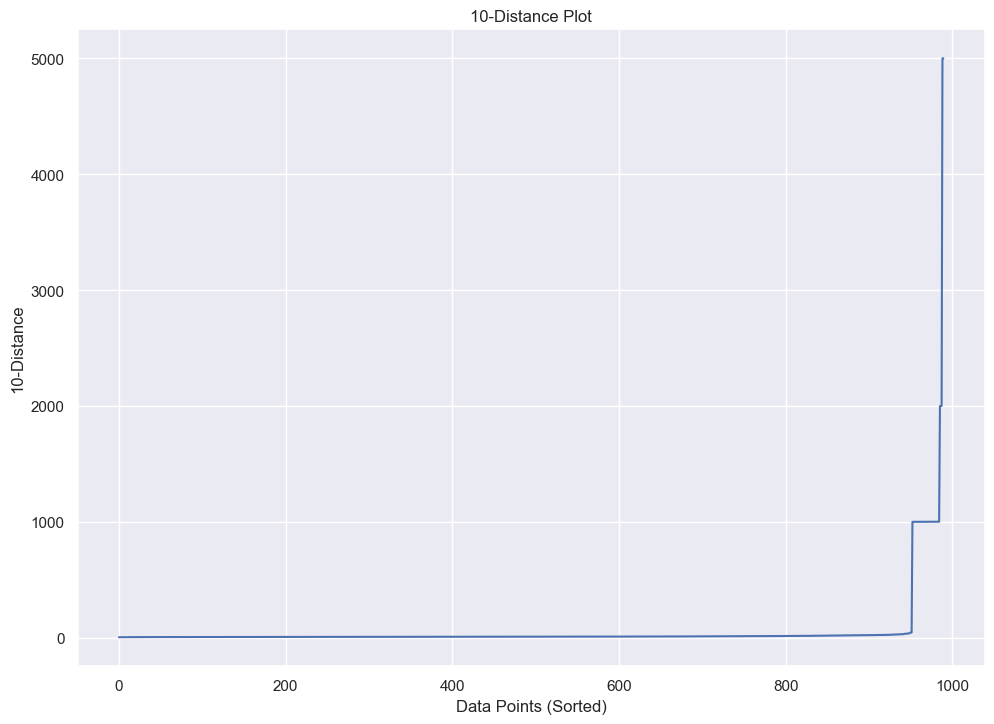

In [71]:

k = 10 #50 

# Calculate the distances to the k-th nearest neighbors for each data point
nbrs = NearestNeighbors(n_neighbors=k).fit(data[train_cols])
distances, _ = nbrs.kneighbors(data[train_cols])
k_distances = np.sort(distances[:, -1]) 

plt.plot(range(len(data)), k_distances)
plt.xlabel('Data Points (Sorted)')
plt.ylabel(f'{k}-Distance')
plt.title(f'{k}-Distance Plot')

plt.show()

In [72]:
eps = 1000  # Maximum distance between two samples to be considered as in the same neighborhood
min_samples = 10  # Minimum number of samples in a neighborhood for a data point to be considered a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(data[train_cols])
data['Cluster'] = dbscan.labels_
anomalies = data['Cluster'] == -1
data['Is Anomaly'] = anomalies

In [73]:
anomali_data = data[data['Is Anomaly'] == True]

In [74]:
silhouette_avg = silhouette_score(data[train_cols], data['Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9155862454259193


Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.

1: Means clusters are well apart from each other and clearly distinguished.

0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.

-1: Means clusters are assigned in the wrong way.

[https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c]

In [ ]:
sns.pairplot(data, hue='Is Anomaly', palette={True:'red',False:'blue'})

# LocalOutlierFactor

In [ ]:
# data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
# # data = data.drop('ID',axis=1)
# data = data.reset_index(drop=True)

In [75]:
from sklearn.neighbors import LocalOutlierFactor
model = LocalOutlierFactor(contamination='auto')
y_train_pred = model.fit_predict(data[train_cols])
data['LocalOutlierFactor'] = y_train_pred
anomali_data = data[data['LocalOutlierFactor'] == -1]

In [76]:
silhouette_avg = silhouette_score(data[train_cols], data['LocalOutlierFactor'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.14747345358988465


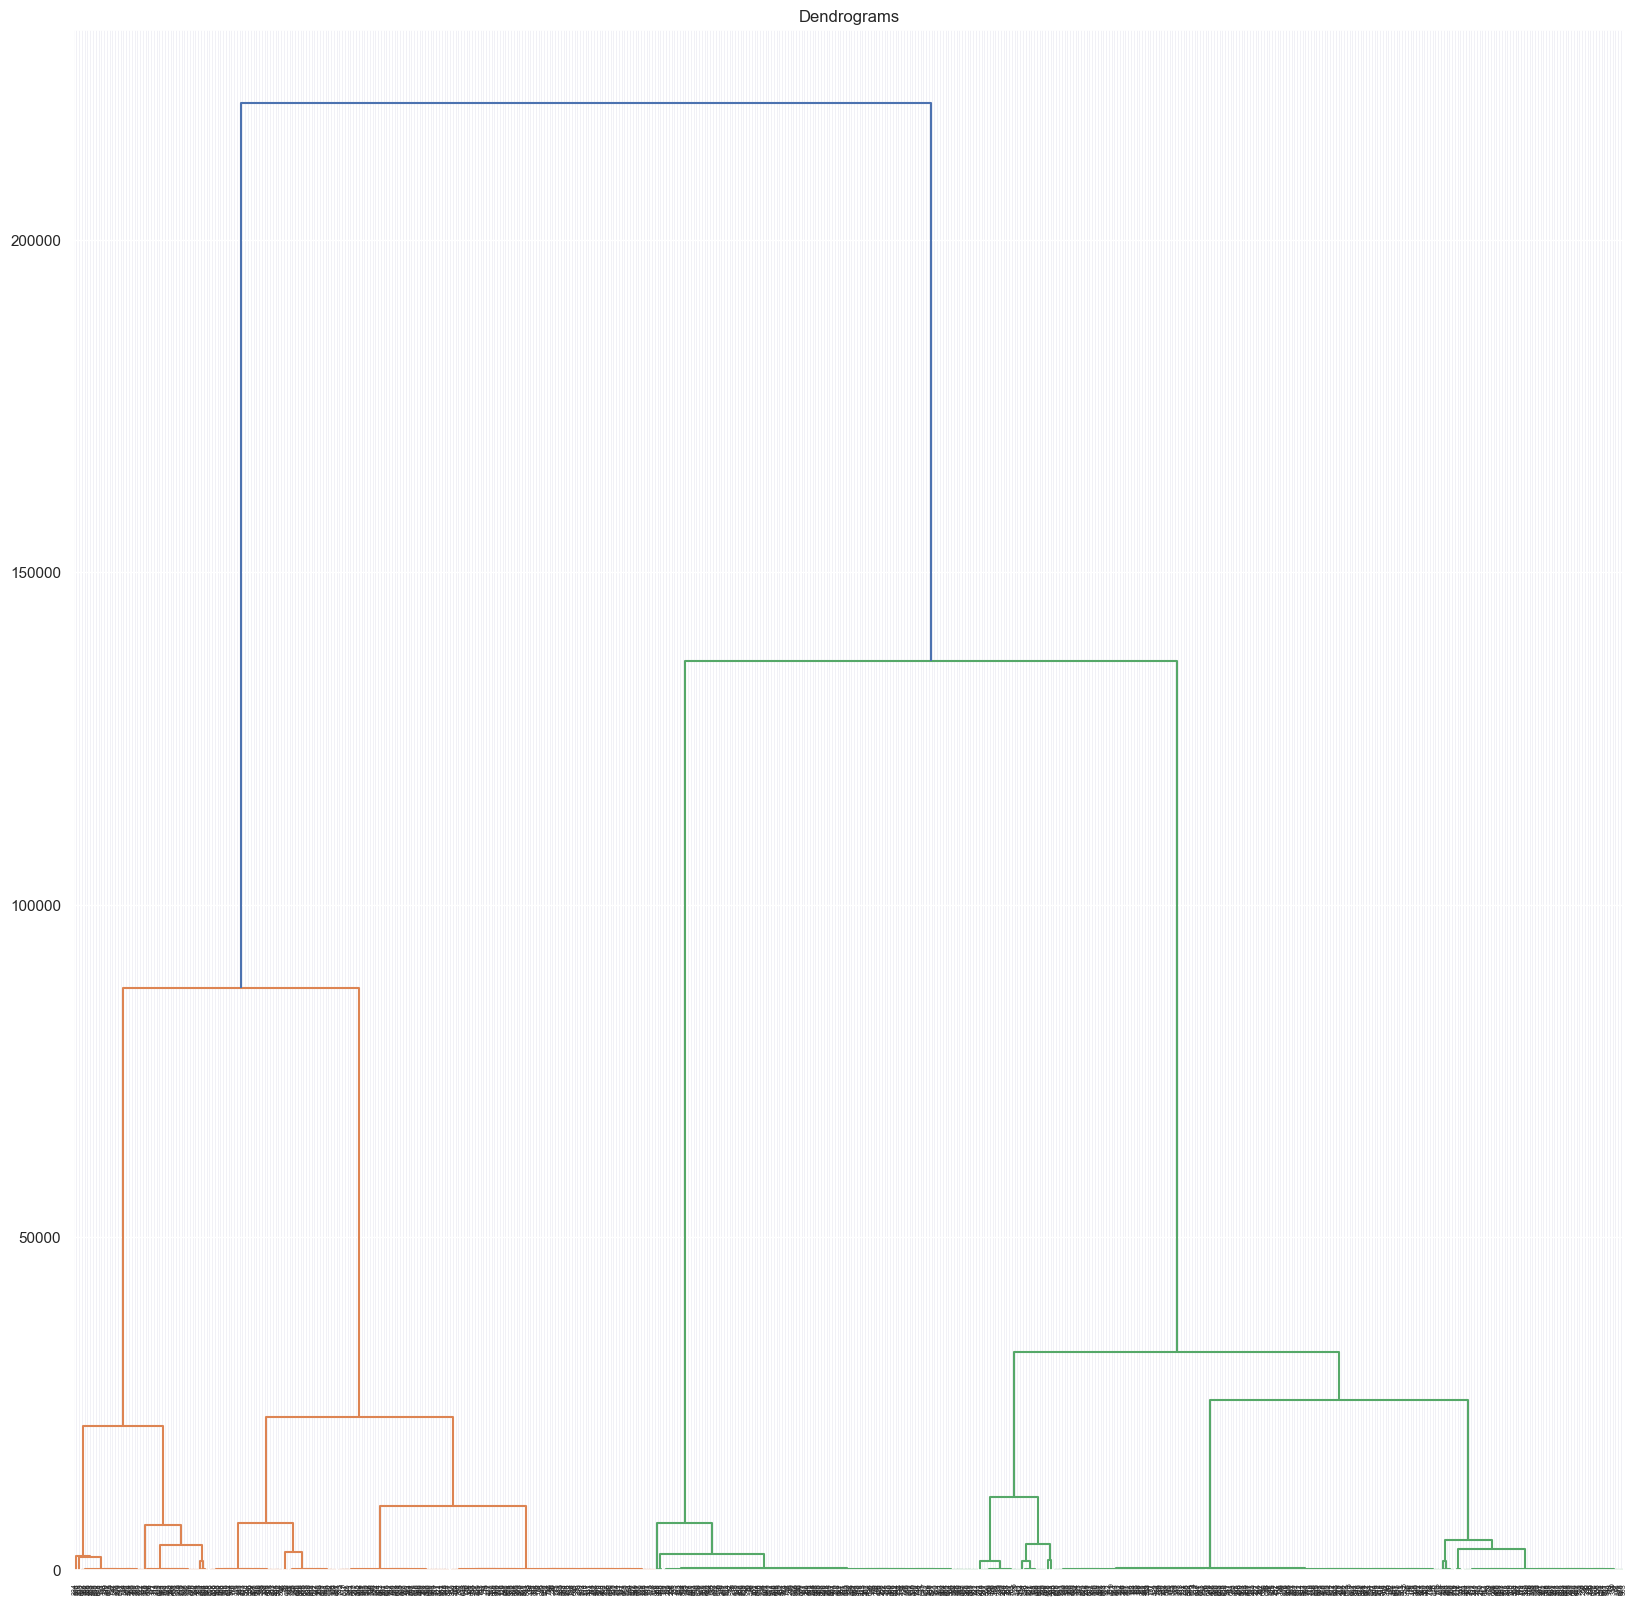

In [77]:
import scipy.cluster.hierarchy as shc
from matplotlib import pyplot
pyplot.figure(figsize=(20, 20))  
pyplot.title("Dendrograms")  
dend = shc.dendrogram(shc.linkage(data[train_cols], method='ward'))

# Scaled Data

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
scaled_data = scaled_data.reset_index(drop=True)

# scaled_data['Age'] = scaler.fit_transform(scaled_data['Age'].values.reshape(-1,1))
scaled_data['Height'] = scaler.fit_transform(scaled_data['Height'].values.reshape(-1,1))
scaled_data['Weight'] = scaler.fit_transform(scaled_data['Weight'].values.reshape(-1,1))
scaled_data['BMI'] = scaler.fit_transform(scaled_data['BMI'].values.reshape(-1,1))
# scaled_data['PremiumPrice'] = scaler.fit_transform(scaled_data['PremiumPrice'].values.reshape(-1,1))


In [82]:
k = 10 # Number of neighbors (k)
nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto',metric='l2').fit(scaled_data[train_cols])

distances, indices = nbrs.kneighbors(scaled_data[train_cols])

scaled_data['knn_distances'] = np.mean(distances, axis=1) # k-NN distances for each point
scaled_data['neighbors'] = indices.tolist()
scaled_data['neighbors_dist'] = distances.tolist()
threshold_s = np.mean(scaled_data['knn_distances']) + 2 * np.std(scaled_data['knn_distances']) # Mean + 2 * std

anomalies_s = scaled_data['knn_distances'] > threshold_s
scaled_data['Is Anomaly'] = anomalies_s

anomali_data_new = scaled_data[scaled_data['Is Anomaly'] == True]

In [83]:
# Importing the libraries 
from scipy.cluster import hierarchy 
from scipy.cluster.hierarchy import dendrogram 

Z = hierarchy.linkage(scaled_data, method='ward') 
  

# plt.title("Dendrograms") 
  
# Dendrogram plotting using linkage matrix 
dendrogram = hierarchy.dendrogram(Z) 
plt.show()


ValueError: setting an array element with a sequence.

# DB Scan

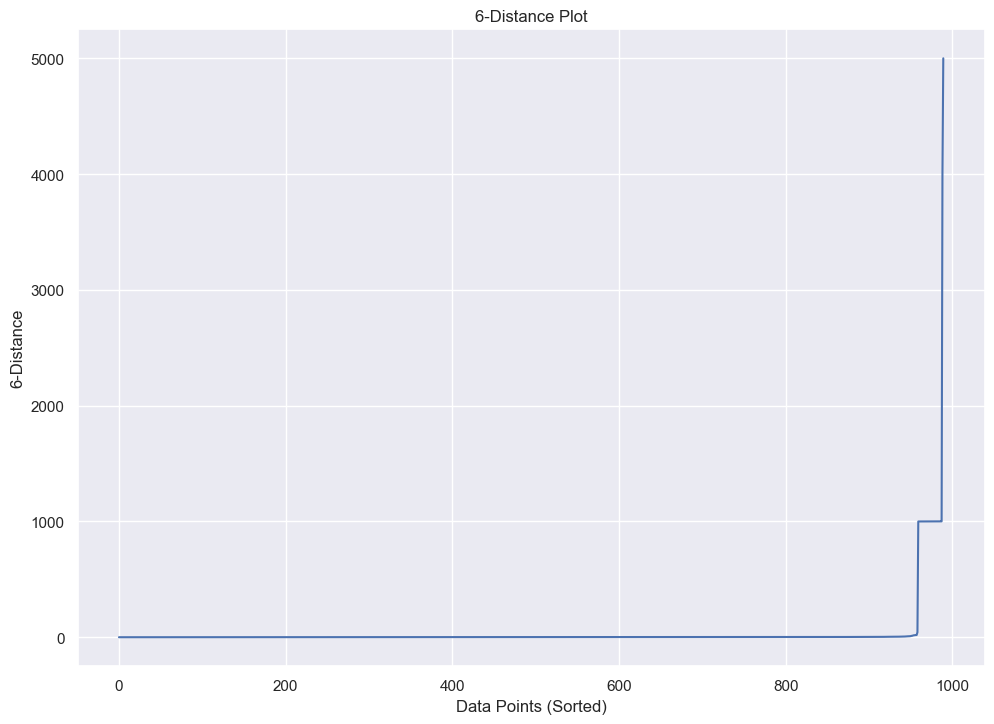

In [84]:
k = 6 #50 

# Calculate the distances to the k-th nearest neighbors for each data point
nbrs = NearestNeighbors(n_neighbors=k).fit(scaled_data[train_cols])
distances, _ = nbrs.kneighbors(scaled_data[train_cols])
k_distances = np.sort(distances[:, -1]) 

plt.plot(range(len(scaled_data)), k_distances)
plt.xlabel('Data Points (Sorted)')
plt.ylabel(f'{k}-Distance')
plt.title(f'{k}-Distance Plot')

plt.show()

In [85]:
eps = 1000 #1000  # Maximum distance between two samples to be considered as in the same neighborhood
min_samples = 24 #6  # Minimum number of samples in a neighborhood for a data point to be considered a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(scaled_data[train_cols])
scaled_data['Cluster'] = dbscan.labels_
anomalies = scaled_data['Cluster'] == -1
scaled_data['Is Anomaly'] = anomalies

In [86]:
anomali_data_new = scaled_data[scaled_data['Is Anomaly'] == True]

In [87]:
(len(anomali_data_new) / len(scaled_data)) * 100 

5.353535353535353

[0.         1.19770314 1.41573163 1.42549711 1.42803509 1.45543316]


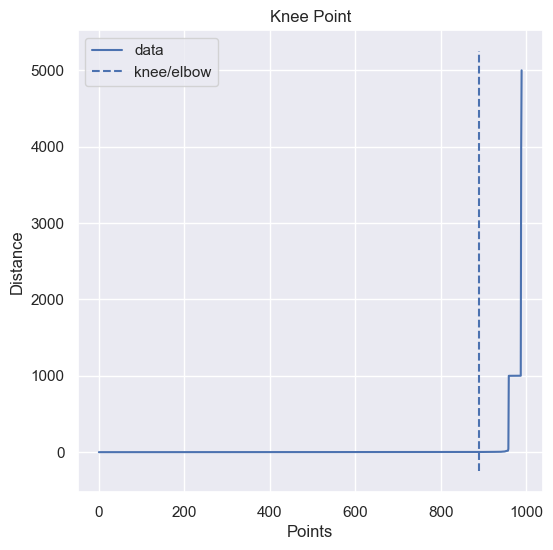

In [88]:
# parameter tuning for eps
from kneed import KneeLocator
i = np.arange(len(distances))
knee = KneeLocator(range(len(scaled_data)), k_distances, S=1, curve='convex', direction='increasing', interp_method='polynomial')
# plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
print(distances[knee.knee])

In [89]:
(9 / len(scaled_data)) * 100 

0.9090909090909091

In [90]:
silhouette_avg = silhouette_score(scaled_data[train_cols], scaled_data['Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.8990438592411308


# HDBSCAN

In [91]:
from hdbscan import HDBSCAN
# hdbscan = HDBSCAN(min_cluster_size=5, min_samples = 10)
hdbscan = HDBSCAN(min_samples = 10)

scaled_data['HDBSCAN_cluster'] = hdbscan.fit_predict(scaled_data[train_cols])

In [92]:
h = hdbscan.fit(scaled_data[train_cols])
h.get_params()
scaled_data['HDBSCAN_cluster_outlier_score'] = h.outlier_scores_

In [93]:
anomali_data_hdbscan = scaled_data[scaled_data['HDBSCAN_cluster'] == -1]

In [94]:
silhouette_avg = silhouette_score(scaled_data[train_cols], scaled_data['HDBSCAN_cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9466906517025359


# One Class SVM

In [85]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random
import matplotlib.pyplot as plt

In [171]:
svm = OneClassSVM(kernel='rbf', degree=5, gamma='scale', coef0=0.0, tol=0.01, nu=0.03, 
                       shrinking=True, cache_size=200, verbose=False, max_iter=- 1)

In [172]:
svm.fit(scaled_data[train_cols])
scaled_data['One_class_SVM'] = svm.predict(scaled_data[train_cols])

In [173]:
silhouette_avg = silhouette_score(scaled_data[train_cols], scaled_data['One_class_SVM'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.48423297906081003


In [174]:
svm = scaled_data[scaled_data['One_class_SVM'] == -1]

In [175]:
svm

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,One_class_SVM
147,59,0,1,1,0,0.093023,0.209877,0,0,0,38000,0.444068,-1
204,27,0,1,0,0,0.325581,0.851852,1,1,1,39000,0.927289,-1
218,62,0,1,1,0,0.441860,0.864198,1,0,1,38000,0.856161,-1
289,64,0,1,1,0,0.720930,0.246914,0,1,1,38000,0.222843,-1
295,64,1,1,0,1,0.418605,0.493827,0,0,2,40000,0.547994,-1
314,59,1,1,1,0,0.302326,0.333333,0,0,1,38000,0.461739,-1
459,58,0,0,1,0,0.790698,0.135802,0,0,0,38000,0.120364,-1
683,59,0,0,1,1,0.790698,0.135802,0,0,0,38000,0.120364,-1
708,56,1,0,1,0,0.930233,0.604938,0,0,0,38000,0.403577,-1
926,24,0,1,0,0,0.325581,0.197531,0,0,0,39000,0.325621,-1


In [99]:
(len(svm) / len(scaled_data)) * 100 

5.95959595959596

In [100]:
li1 = svm.index.tolist()
li2 = anomali_data_new.index.tolist()
s = set(li2)
temp3 = [x for x in li1 if x not in s]
print(temp3)

[13, 14, 73, 88, 142, 207, 218, 269, 289, 290, 416, 445, 476, 520, 532, 584, 586, 602, 627, 656, 669, 740, 764, 765, 783, 831, 840, 908]


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Diabetes'}>,
        <Axes: title={'center': 'BloodPressureProblems'}>,
        <Axes: title={'center': 'AnyTransplants'}>],
       [<Axes: title={'center': 'AnyChronicDiseases'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'KnownAllergies'}>],
       [<Axes: title={'center': 'HistoryOfCancerInFamily'}>,
        <Axes: title={'center': 'NumberOfMajorSurgeries'}>,
        <Axes: title={'center': 'PremiumPrice'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'knn_distances'}>,
        <Axes: title={'center': 'Cluster'}>,
        <Axes: title={'center': 'HDBSCAN_cluster'}>,
        <Axes: title={'center': 'HDBSCAN_cluster_outlier_score'}>],
       [<Axes: title={'center': 'One_class_SVM'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

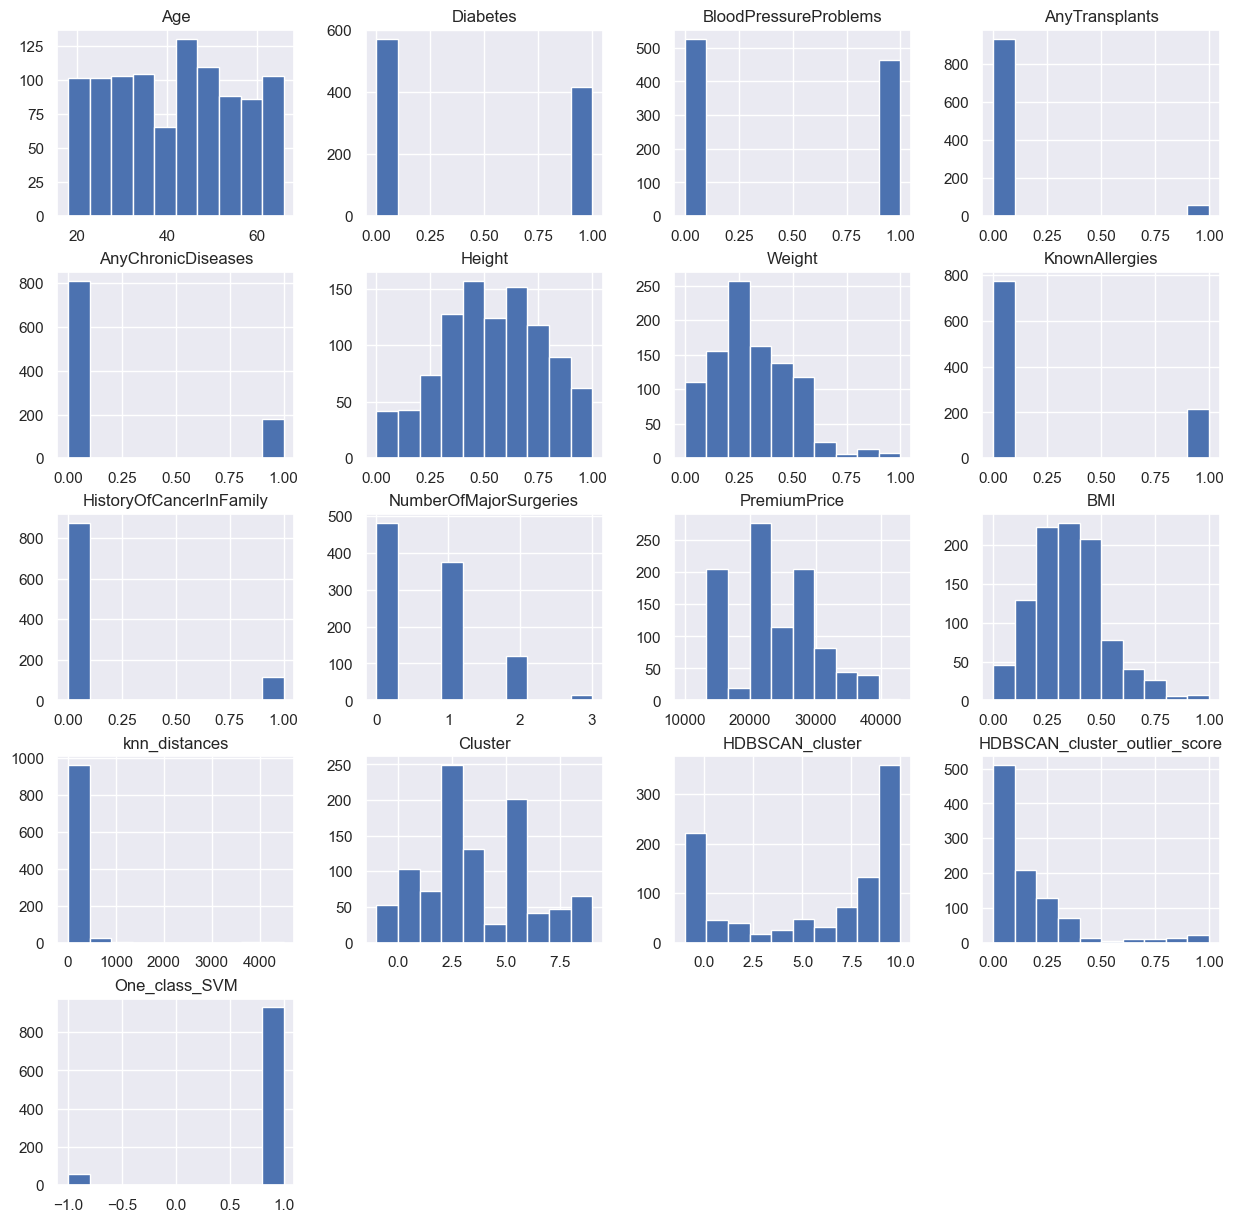

In [101]:
scaled_data.hist(figsize=(15,15))

In [6]:
dataset_size = len(scaled_data[train_cols])  

# Define a fraction or proportion of the dataset size to set the range
min_cluster_size_fraction = 0.01  # 1% of the dataset size
min_samples_fraction = 0.005  # 0.5% of the dataset size

# Calculate the ranges for min_cluster_size and min_samples based on fractions
min_cluster_size_range = range(int(dataset_size * min_cluster_size_fraction), int(dataset_size * 0.1))  # Range: 1% to 10% of dataset size
min_samples_range = range(int(dataset_size * min_samples_fraction), int(dataset_size * 0.05))  # Range: 0.5% to 5% of dataset size

print("min_cluster_size_range:", min_cluster_size_range)
print("min_samples_range:", min_samples_range)

min_cluster_size_range: range(9, 99)
min_samples_range: range(4, 49)


In [7]:
import hdbscan
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score


best_score = -1
best_min_cluster_size = None
best_min_samples = None

# Iterate over potential values for min_cluster_size and min_samples
for min_cluster_size in min_cluster_size_range:
    for min_samples in min_samples_range:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,gen_min_span_tree=True)
        # clusterer = hdbscan.HDBSCAN(min_samples=min_samples)

        cluster_labels = clusterer.fit_predict(scaled_data[train_cols])

        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        if n_clusters <= 1:  # Avoid single cluster scenario
            continue

        silhouette_avg = silhouette_score(scaled_data[train_cols], cluster_labels)
        
        # Update best parameters if silhouette score is higher
        if silhouette_avg > best_score:
            best_score = silhouette_avg
            best_min_cluster_size = min_cluster_size
            best_min_samples = min_samples
            best_model = clusterer

print("Best min_cluster_size:", best_min_cluster_size)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", best_score)

Best min_cluster_size: 9
Best min_samples: 5
Best Silhouette Score: 0.9510597371929531


C:\Users\akhanna\AppData\Local\Temp\ipykernel_33476\2853363754.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clusterer.outlier_scores_[np.isfinite(clusterer.outlier_scores_)], rug=True)


<Axes: ylabel='Density'>

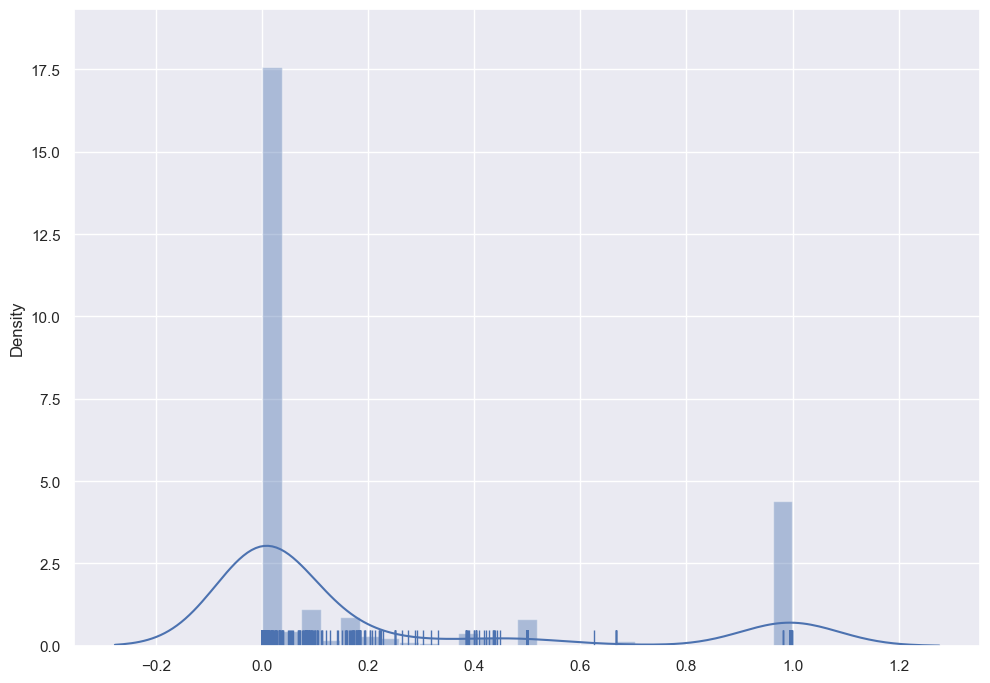

In [107]:
sns.distplot(clusterer.outlier_scores_[np.isfinite(clusterer.outlier_scores_)], rug=True)


In [109]:
threshold = pd.Series(clusterer.outlier_scores_).quantile(0.9)
outliers = np.where(clusterer.outlier_scores_ > threshold)[0]


In [110]:
scaled_data['HDBSCAN_outlier_score'] = clusterer.outlier_scores_

In [111]:
scaled_data[scaled_data['HDBSCAN_outlier_score']  > threshold]

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,...,BMI,knn_distances,neighbors,neighbors_dist,Is Anomaly,Cluster,HDBSCAN_cluster,HDBSCAN_cluster_outlier_score,One_class_SVM,HDBSCAN_outlier_score
16,42,0,0,0,1,0.093023,0.197531,0,0,0,...,0.431141,1.063741,"[16, 588, 748, 629, 126, 585, 632, 210, 590, 776]","[0.0, 0.8910452137613615, 0.9367389503106185, ...",False,7,5,0.000000,1,0.994898
38,43,0,0,0,1,0.651163,0.370370,0,1,1,...,0.341748,1.295684,"[38, 405, 776, 126, 585, 616, 363, 695, 588, 272]","[0.0, 1.0960337806137412, 1.20383142018485, 1....",False,7,5,0.051855,1,0.994898
71,55,0,1,0,1,0.279070,0.530864,0,0,1,...,0.659492,3.977083,"[71, 239, 862, 770, 563, 842, 700, 666, 469, 170]","[0.0, 2.003247910144767, 2.0763716437034416, 2...",False,7,5,0.765670,1,0.994898
88,35,1,1,0,0,0.279070,0.197531,1,1,1,...,0.345122,3.559044,"[88, 627, 435, 935, 127, 870, 451, 820, 303, 296]","[0.0, 1.753857286007493, 2.278638490150814, 3....",False,9,6,0.491110,-1,0.994898
92,52,0,0,0,0,0.325581,0.308642,1,1,1,...,0.427791,4.052678,"[92, 830, 613, 680, 934, 850, 545, 622, 102, 799]","[0.0, 1.7811241185263078, 2.00742150780564, 2....",False,9,6,0.672304,1,0.994898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,54,1,1,0,0,0.348837,0.234568,0,1,1,...,0.349775,4.376653,"[934, 680, 830, 92, 613, 102, 850, 329, 545, 370]","[0.0, 1.1610948128511507, 2.039859524736219, 2...",False,9,6,0.673157,1,0.994898
935,38,0,1,0,1,0.581395,0.246914,0,1,1,...,0.270097,2.062971,"[935, 451, 127, 870, 435, 296, 820, 303, 627, ...","[0.0, 1.7694442908718648, 1.7970905000934705, ...",False,9,6,0.236496,1,0.994898
940,40,1,1,0,1,0.232558,0.185185,0,0,1,...,0.353438,1.711951,"[940, 771, 268, 637, 357, 629, 632, 210, 590, 16]","[0.0, 1.0033650562142475, 1.4458063209335978, ...",False,7,5,0.375806,1,0.994898
978,40,0,1,1,0,0.534884,0.234568,0,0,0,...,0.276816,1102.290686,"[978, 988, 333, 448, 446, 450, 444, 386, 706, ...","[0.0, 22.11644400968675, 1000.0065473105527, 1...",True,-1,-1,0.000015,-1,0.998874


<Axes: >

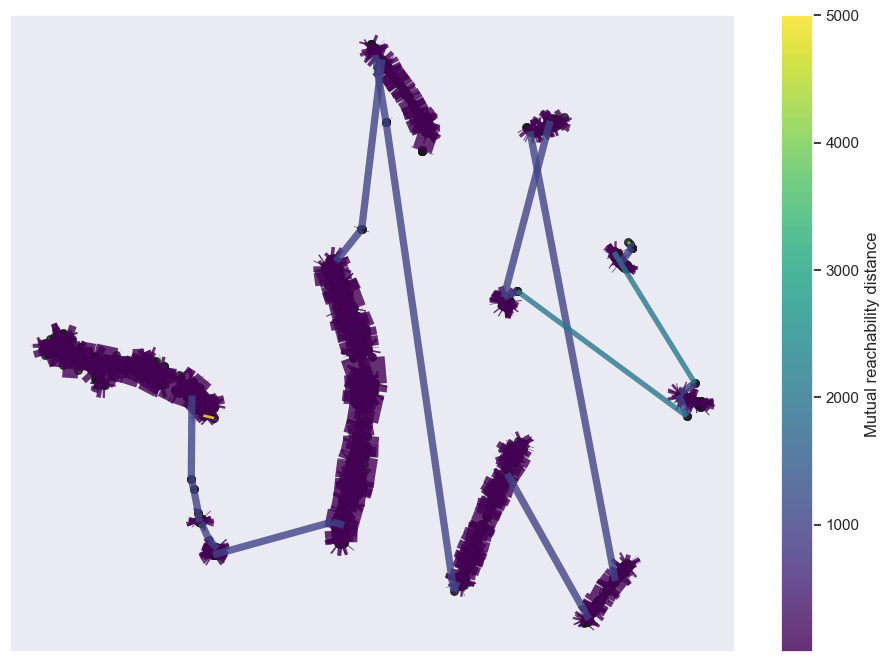

In [112]:
import hdbscan
# min_samples ->This parameter determines the minimum number of samples in a neighborhood for a point to be considered a core point.
# min_cluster_size -> It's the size threshold for considering a set of connected core points as a cluster
clusterer = hdbscan.HDBSCAN(min_cluster_size=9, min_samples=4,gen_min_span_tree=True)
clusterer.fit(scaled_data[train_cols])
clusterer.minimum_spanning_tree_.plot(edge_cmap='viridis',
                                      edge_alpha=0.8,
                                      node_size=30,
                                      edge_linewidth=2)

<Axes: ylabel='distance'>

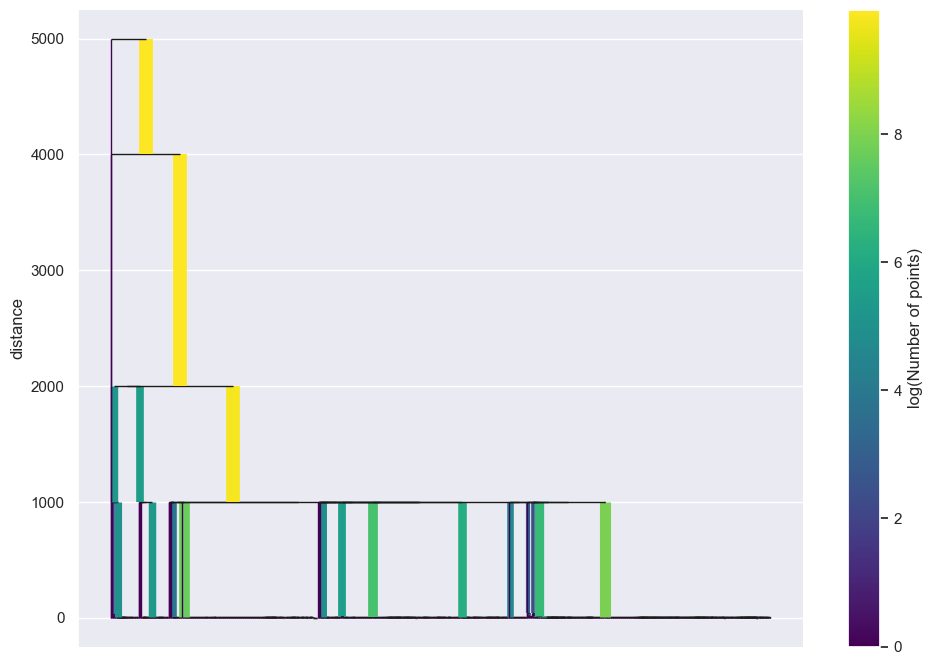

In [113]:
clusterer.single_linkage_tree_.plot(cmap='viridis', colorbar=True)


<Axes: ylabel='$\\lambda$ value'>

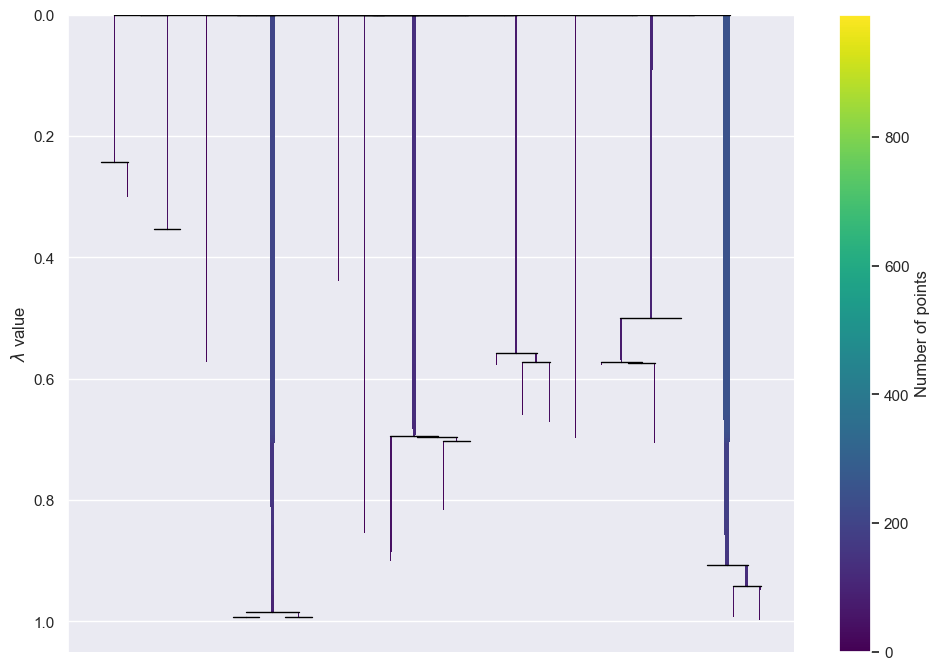

In [50]:
clusterer.condensed_tree_.plot()


<Axes: ylabel='$\\lambda$ value'>

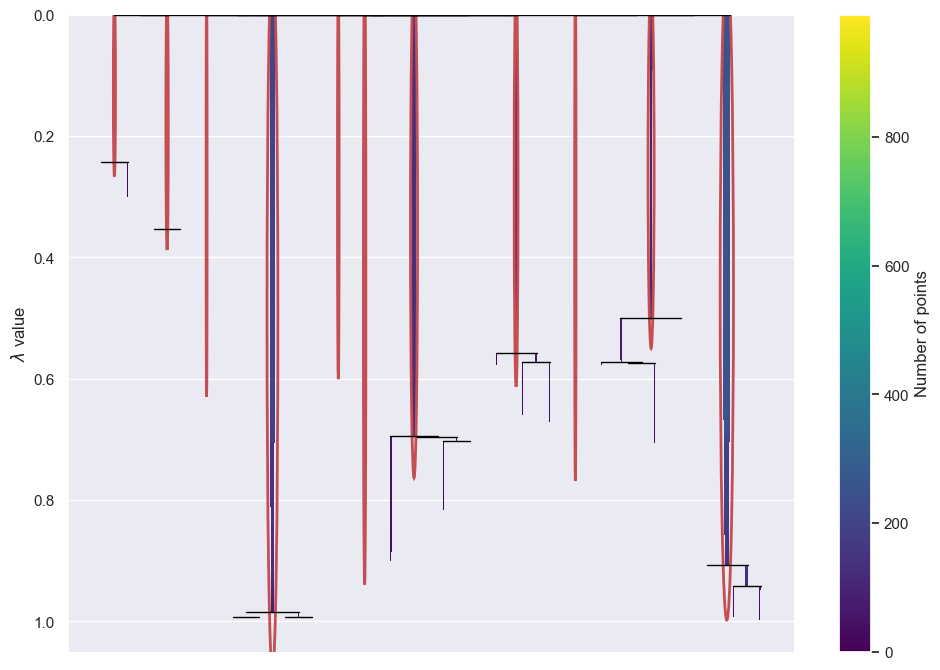

In [51]:
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())


In [52]:
silhouette_score(scaled_data[train_cols],clusterer.labels_)

0.9498410069029614

In [ ]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=9, gen_min_span_tree=True)
clusterer.fit(scaled_data[train_cols])

In [ ]:
HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
    gen_min_span_tree=True, leaf_size=40, metric='euclidean', min_cluster_size=5, min_samples=None, p=None)

In [ ]:
clusterer.minimum_spanning_tree_.plot(edge_cmap='viridis',
                                      edge_alpha=0.6,
                                      node_size=80,
                                      edge_linewidth=2)

In [ ]:
clusterer.single_linkage_tree_.plot(cmap='viridis', colorbar=True)


In [ ]:
clusterer.condensed_tree_.plot()


In [ ]:
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())


In [ ]:
silhouette_score(scaled_data[train_cols],clusterer.labels_)